Predicting high site traffic




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Data wrangling


Data import

In [ ]:
df = pd.read_csv("data/recipe_site_traffic.csv") # to import my data
df.head() # to show the first rows (head) of my data

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [ ]:
df.tail() # to show the last rows (tail) of my data

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
942,943,1161.00,5.31,22.39,44.22,Lunch/Snacks,2,NaN
943,944,NaN,NaN,NaN,NaN,Potato,2,High
944,945,951.74,29.42,3.57,13.87,Pork,2,High
945,946,266.61,35.77,0.97,8.07,Potato,6,High
946,947,184.56,45.21,6.20,0.03,Beverages,4,NaN


In [ ]:
df.info() # to get more information about my data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


In [ ]:
df.shape

(947, 8)

Data cleaning

In [ ]:
df.isna().sum() # to have an idea about missing values in my dataset

,0
recipe,0
calories,52
carbohydrate,52
sugar,52
protein,52
category,0
servings,0
high_traffic,373


In [ ]:
df['high_traffic'].unique()

array(['High', nan], dtype=object)

Let's start replacing "nan" of high_traffic by "Low"


In [ ]:
df['high_traffic'].fillna('Low', inplace=True)

/tmp/ipython-input-3054423319.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['high_traffic'].fillna('Low', inplace=True)


In [ ]:
df.isna().sum()

,0
recipe,0
calories,52
carbohydrate,52
sugar,52
protein,52
category,0
servings,0
high_traffic,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dropna(inplace=True) # to drop rows where there are missing values
df

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,Low
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,Low
5,6,691.15,3.46,1.65,53.93,One Dish Meal,2,High
...,...,...,...,...,...,...,...,...
941,942,186.21,83.94,1.98,22.40,Chicken Breast,4,High
942,943,1161.00,5.31,22.39,44.22,Lunch/Snacks,2,Low
944,945,951.74,29.42,3.57,13.87,Pork,2,High
945,946,266.61,35.77,0.97,8.07,Potato,6,High


In [ ]:
df.shape

(895, 8)

After removing the missing values, 895 rows remain, which represents 94.51% of the initial dataset. With such a highly representative percentage, removing the missing values will not distort the results.

# 2. Exploratory Data Analysis (EDA)

In [ ]:
df.describe() # to show some descriptive statistics of numerical variables

,recipe,calories,carbohydrate,sugar,protein
count,895.000000,895.000000,895.000000,895.000000,895.000000
mean,473.652514,435.939196,35.069676,9.046547,24.149296
std,272.763283,453.020997,43.949032,14.679176,36.369739
min,2.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,475.000000,288.550000,21.480000,4.550000,10.800000
75%,708.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


In [ ]:
df.describe(include='object') # to show some descriptive statistics of object variables

,category,servings,high_traffic
count,895,895,895
unique,11,6,2
top,Breakfast,4,High
freq,106,365,535


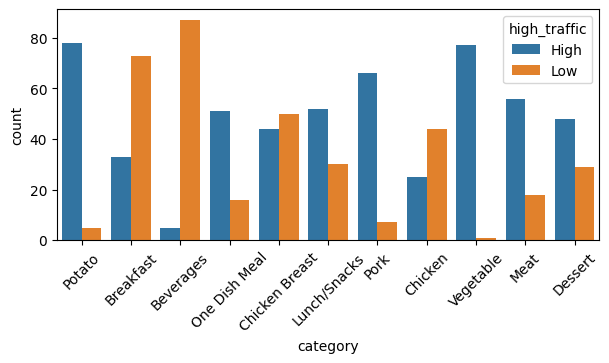

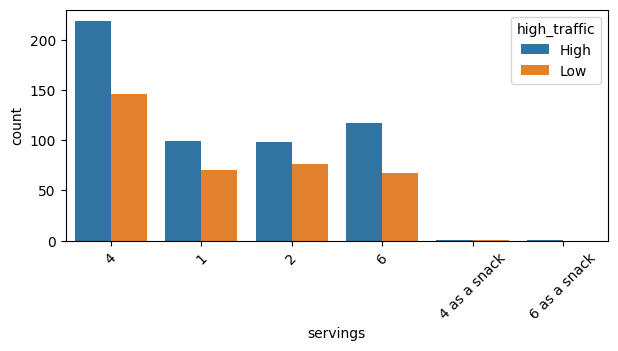

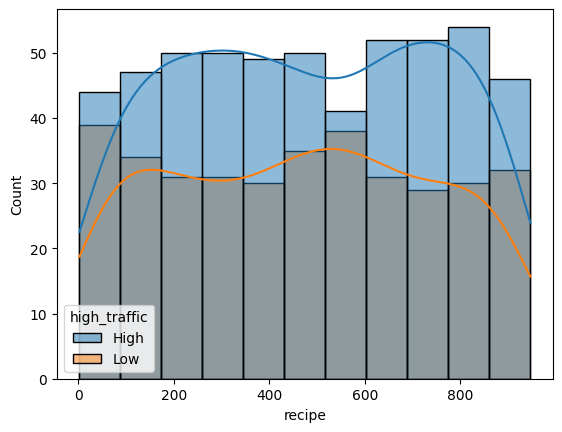

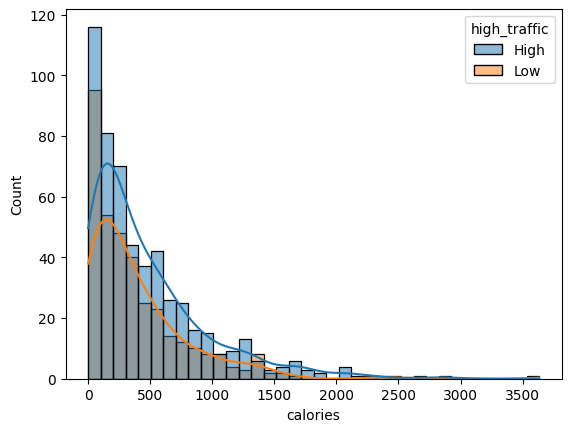

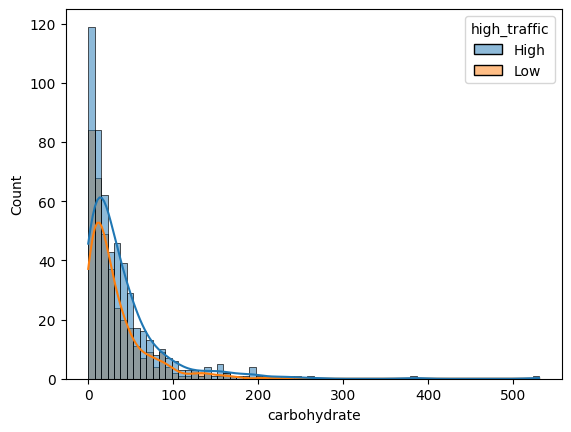

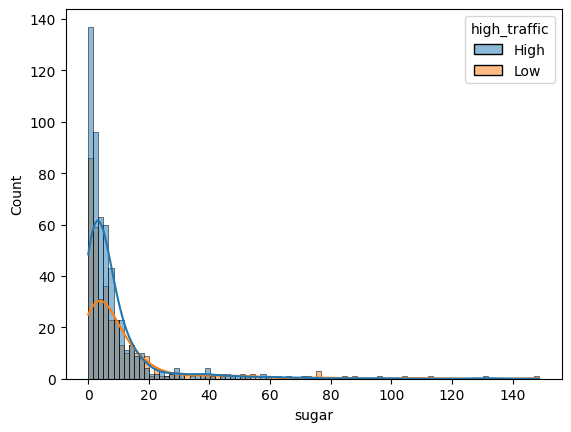

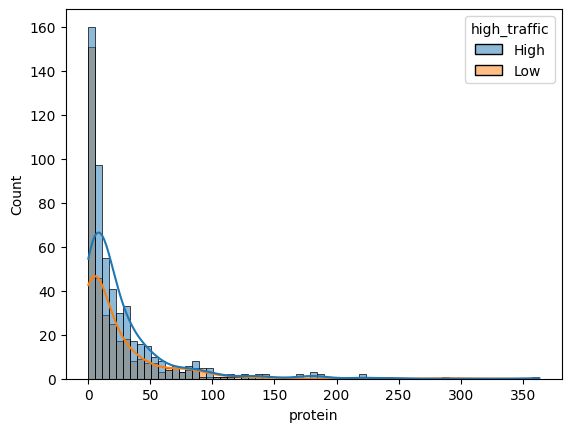

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.drop('high_traffic') # to store qualitative variables excluding 'high_traffic'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns # to store numerical variables
for c in cat_cols:
  plt.figure(figsize=(7, 3))
  sns.countplot(data=df, x=c, hue=df['high_traffic']) # to draw barplot for each qualitative variable in function of 'high_traffic'
  plt.xticks(rotation=45)
  plt.show()
for n in num_cols:
  sns.histplot(data=df, x=n, hue=df['high_traffic'], kde= True) # to draw histogram with density for each quantitative variable in function of 'high_traffic'
  plt.show()

# Interpretation
* For the variable category, we observe that the dishes Potato, One Dish Meal, Lunch/Snacks, Vegetable, and Meat are associated with high traffic, whereas the dishes Breakfast, Beverages, Chicken Breast, Pork, and Chicken are associated with low traffic.

* High traffic is predominant across all serving sizes, particularly for recipes with 4 servings, which are both the most frequent and the most strongly associated with high traffic.

* For the numerical variables, we observe that higher values are generally associated with higher traffic.



# 3. Split the data into training and test set


In [ ]:
# First of all, let's recode our target variable (high-traffic)
conditions = [
    (df['high_traffic'] == 'High'),
    (df['high_traffic'] == 'Low')
]

values = [
    1, 0
  ]

df['high_traffic'] = np.select(conditions, values, default= pd.NA)
df['high_traffic'] = df['high_traffic'].astype('Int64')

In [ ]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
1,2,35.48,38.56,0.66,0.92,Potato,4,1
2,3,914.28,42.68,3.09,2.88,Breakfast,1,0
3,4,97.03,30.56,38.63,0.02,Beverages,4,1
4,5,27.05,1.85,0.80,0.53,Beverages,4,0
5,6,691.15,3.46,1.65,53.93,One Dish Meal,2,1


In [ ]:
df['category'].unique()

array(['Potato', 'Breakfast', 'Beverages', 'One Dish Meal',
       'Chicken Breast', 'Lunch/Snacks', 'Pork', 'Chicken', 'Vegetable',
       'Meat', 'Dessert'], dtype=object)

In [ ]:
df = pd.get_dummies(
    df,
    columns=['category'],
    drop_first=True,
    prefix='cat',
    prefix_sep='_',
    dtype='int64'
)


In [ ]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,servings,high_traffic,cat_Breakfast,cat_Chicken,cat_Chicken Breast,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
1,2,35.48,38.56,0.66,0.92,4,1,0,0,0,0,0,0,0,0,1,0
2,3,914.28,42.68,3.09,2.88,1,0,1,0,0,0,0,0,0,0,0,0
3,4,97.03,30.56,38.63,0.02,4,1,0,0,0,0,0,0,0,0,0,0
4,5,27.05,1.85,0.80,0.53,4,0,0,0,0,0,0,0,0,0,0,0
5,6,691.15,3.46,1.65,53.93,2,1,0,0,0,0,0,0,1,0,0,0


In [ ]:
df['servings'].unique()

array(['4', '1', '2', '6', '4 as a snack', '6 as a snack'], dtype=object)

In [ ]:
df['servings'] = df['servings'].str.extract('(\d+)') # to remove some strings


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-355889649.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['servings'] = df['servings'].str.extract('(\d+)') # to remove some strings


In [ ]:
df['servings'].unique()

array(['4', '1', '2', '6'], dtype=object)

In [ ]:
df['servings'] = df['servings'].astype('Int64') # to convert the variable into integer

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 895 entries, 1 to 946
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   recipe              895 non-null    int64  
 1   calories            895 non-null    float64
 2   carbohydrate        895 non-null    float64
 3   sugar               895 non-null    float64
 4   protein             895 non-null    float64
 5   servings            895 non-null    Int64  
 6   high_traffic        895 non-null    Int64  
 7   cat_Breakfast       895 non-null    int64  
 8   cat_Chicken         895 non-null    int64  
 9   cat_Chicken Breast  895 non-null    int64  
 10  cat_Dessert         895 non-null    int64  
 11  cat_Lunch/Snacks    895 non-null    int64  
 12  cat_Meat            895 non-null    int64  
 13  cat_One Dish Meal   895 non-null    int64  
 14  cat_Pork            895 non-null    int64  
 15  cat_Potato          895 non-null    int64  
 16  cat_Vegetable

In [ ]:
df.head()

,recipe,calories,carbohydrate,sugar,protein,servings,high_traffic,cat_Breakfast,cat_Chicken,cat_Chicken Breast,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
1,2,35.48,38.56,0.66,0.92,4,1,0,0,0,0,0,0,0,0,1,0
2,3,914.28,42.68,3.09,2.88,1,0,1,0,0,0,0,0,0,0,0,0
3,4,97.03,30.56,38.63,0.02,4,1,0,0,0,0,0,0,0,0,0,0
4,5,27.05,1.85,0.80,0.53,4,0,0,0,0,0,0,0,0,0,0,0
5,6,691.15,3.46,1.65,53.93,2,1,0,0,0,0,0,0,1,0,0,0


We are going to split our dataset into a train_set and a test_set according to an 80/20 ratio. Before this, we create the matrix x for our explanatory variables and the matrix y for our target variable. We then assess model performance on the held-out test set.

In [ ]:
# Let's create the matrix x and y
x = df.drop('high_traffic', axis=1)
y = df['high_traffic']

In [ ]:
x.head()

,recipe,calories,carbohydrate,sugar,protein,servings,cat_Breakfast,cat_Chicken,cat_Chicken Breast,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable
1,2,35.48,38.56,0.66,0.92,4,0,0,0,0,0,0,0,0,1,0
2,3,914.28,42.68,3.09,2.88,1,1,0,0,0,0,0,0,0,0,0
3,4,97.03,30.56,38.63,0.02,4,0,0,0,0,0,0,0,0,0,0
4,5,27.05,1.85,0.80,0.53,4,0,0,0,0,0,0,0,0,0,0
5,6,691.15,3.46,1.65,53.93,2,0,0,0,0,0,0,1,0,0,0


In [ ]:
y.head()

,high_traffic
1,1
2,0
3,1
4,0
5,1


In [ ]:
# Let's split the data into train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=48)

# 4. Estimation of the Linear Probability Model (LPM)

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
train_df = pd.concat([x_train, y_train], axis=1) # in order to construct a new dataframe for x_train and y_train
train_df.head()

,recipe,calories,carbohydrate,sugar,protein,servings,cat_Breakfast,cat_Chicken,cat_Chicken Breast,cat_Dessert,cat_Lunch/Snacks,cat_Meat,cat_One Dish Meal,cat_Pork,cat_Potato,cat_Vegetable,high_traffic
296,297,487.86,142.22,5.21,1.09,6,0,0,0,0,0,0,0,0,1,0,1
550,551,927.15,0.05,1.73,12.29,4,0,0,0,0,0,0,0,0,1,0,1
847,848,88.17,49.37,0.01,0.40,6,0,0,0,0,0,0,0,0,0,0,0
569,570,531.11,3.21,0.84,56.19,1,0,1,0,0,0,0,0,0,0,0,1
829,830,912.77,79.94,1.85,44.36,1,0,0,0,0,0,0,1,0,0,0,1


In [ ]:
lpm_model = smf.ols(
    formula='high_traffic ~ calories + carbohydrate + sugar + protein + servings + cat_Vegetable',
    data=train_df
    ).fit()


In [ ]:
print(lpm_model.summary())

                            OLS Regression Results                            
Dep. Variable:           high_traffic   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     13.81
Date:                Mon, 05 Jan 2026   Prob (F-statistic):           6.94e-15
Time:                        11:26:19   Log-Likelihood:                -465.31
No. Observations:                 716   AIC:                             944.6
Df Residuals:                     709   BIC:                             976.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.4337      0.049      8.848

## Estimation of logit model

In [ ]:
logit_model = smf.logit(
    formula='high_traffic ~ calories + carbohydrate + sugar + protein + servings + cat_Vegetable',
    data=train_df
    ).fit()


         Current function value: 0.603934
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:           high_traffic   No. Observations:                  716
Model:                          Logit   Df Residuals:                      709
Method:                           MLE   Df Model:                            6
Date:                Mon, 05 Jan 2026   Pseudo R-squ.:                  0.1023
Time:                        11:26:19   Log-Likelihood:                -432.42
converged:                      False   LL-Null:                       -481.71
Covariance Type:            nonrobust   LLR p-value:                 4.928e-19
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.3507      0.228     -1.540      0.123      -0.797       0.096
calories          0.0006      0.000      2.894      0.004       0.000       0.001
carbohydrate      0.0061      0.002     

In [ ]:
# Let's define a significance threshold
def significance_stars (p):
  if p < 0.001:
    return '***'
  elif p < 0.05:
    return '**'
  elif p < 0.1:
    return '*'
  else:
    return ''

In [ ]:
# Marginal effect for model_logit
mfx_logit = logit_model.get_margeff(at = "overall").summary_frame()
logit_df = (
    mfx_logit[['dy/dx', 'Std. Err.', 'Pr(>|z|)']]
    .rename(columns = {
        'dy/dx': 'Marginal Effect',
        'Std. Err.': 'Std. Error',
        'Pr(>|z|)': 'logit p'
    })
)

logit_df['logit_stars'] = logit_df['logit p'].apply(significance_stars)
logit_df

,Marginal Effect,Std. Error,logit p,logit_stars
calories,0.000120,0.000040,0.003034,**
carbohydrate,0.001311,0.000437,0.002713,**
sugar,-0.003243,0.001282,0.011413,**
protein,0.000802,0.000500,0.108610,
servings,0.011595,0.009915,0.242199,
cat_Vegetable,6.457259,96473.913326,0.999947,


In [ ]:
# Marginal effect for LPM
lpm_df = (
    lpm_model.summary2().tables[1]
    [['Coef.', 'Std.Err.', 'P>|t|']]
    .rename(columns={
        'Coef.': 'LPM ME',
        'Std.Err.': 'LPM SE',
        'P>|t|': 'LPM p'
    })
)

lpm_df['LPM stars'] = lpm_df['LPM p'].apply(significance_stars)
lpm_df

,LPM ME,LPM SE,LPM p,LPM stars
Intercept,0.433677,0.049015,7.044355e-18,***
calories,0.000121,0.000040,2.299798e-03,**
carbohydrate,0.001251,0.000399,1.808584e-03,**
sugar,-0.003441,0.001285,7.580715e-03,**
protein,0.000827,0.000489,9.110316e-02,*
servings,0.011285,0.010053,2.620308e-01,
cat_Vegetable,0.479334,0.063648,1.536438e-13,***


In [ ]:
# Let's put together the mfx for lpm model and logit model
results_table = (
    lpm_df
    .join(logit_df, how='inner')
)


In [ ]:
# to create a formated columns
results_table['LPM'] = (
    results_table['LPM ME'].round(4).astype(str)
    + results_table['LPM stars']
)

results_table['Logit'] = (
    results_table['Marginal Effect'].round(4).astype(str)
    + results_table['logit_stars']
)


In [ ]:
# Final table
final_table = results_table[['LPM', 'Logit']]
print(final_table)


                     LPM      Logit
calories        0.0001**   0.0001**
carbohydrate    0.0013**   0.0013**
sugar          -0.0034**  -0.0032**
protein          0.0008*     0.0008
servings          0.0113     0.0116
cat_Vegetable  0.4793***     6.4573


# Comparison of the marginal effects of the two models

The marginal effects obtained from the LPM and the logit model are very similar for the continuous variables, both in terms of sign and magnitude. An increase of 100 calories raises the probability of high traffic by about 0.01, while a one-gram increase in carbohydrates increases this probability by approximately 0.0013, with both effects being statistically significant in the two models. In contrast, a one-gram increase in sugar reduces the probability of high traffic by around 0.003, an effect that is negative and significant regardless of the specification. The effects of protein and servings are positive but small—around 0.0008 per gram of protein and 0.011 per serving—and are not statistically significant at the 5% level, indicating no robust impact on the probability of high traffic.

For the categorical variable, with Beverages as the reference category, the LPM indicates that belonging to the Vegetable category increases the probability of high traffic by approximately 0.48 relative to a Beverage product, holding other factors constant. By contrast, the corresponding marginal effect from the logit model is highly unstable and statistically insignificant, with an extremely large estimate and very high uncertainty, reflecting a problem of quasi-perfect separation between the Vegetable and Beverages categories. Overall, while both models yield consistent conclusions for continuous covariates, the LPM provides a more reliable and interpretable estimate for the effect of the Vegetable category in this empirical setting.

In [ ]:

# important variables for logit_model
importance_df = (
    mfx_logit[['z']]
    .rename(columns={'z': 't_stat'})
)

importance_df['importance'] = importance_df['t_stat'].abs()

# drop intercept
importance_df = importance_df.sort_values('importance', ascending=False)

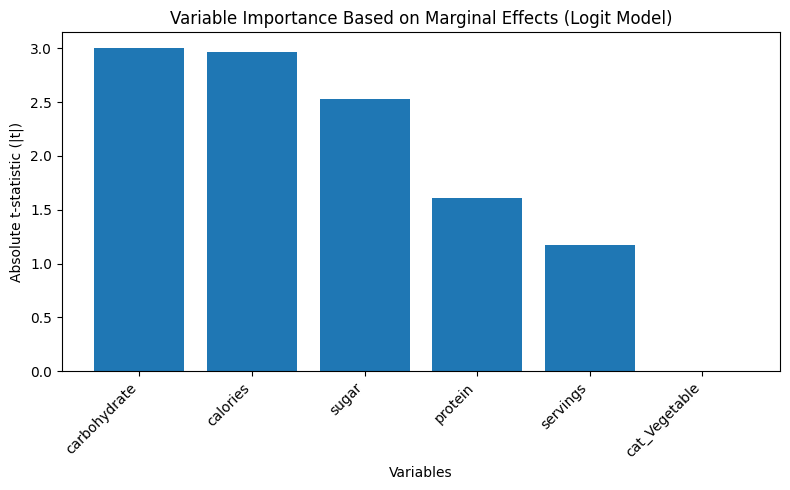

In [ ]:
# Let's plot variables importance for logit_model
plt.figure(figsize=(8, 5))
plt.bar(
    importance_df.index,
    importance_df['importance']
)

plt.ylabel("Absolute t-statistic (|t|)")
plt.xlabel("Variables")
plt.title("Variable Importance Based on Marginal Effects (Logit Model)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
# important variables for lpm_model
# Calculate t-statistic from available columns in lpm_df
importance_df = pd.DataFrame(index=lpm_df.index)
importance_df['t_stat'] = lpm_df['LPM ME'] / lpm_df['LPM SE']

importance_df['importance'] = importance_df['t_stat'].abs()

# drop intercept
importance_df = importance_df.drop('Intercept', errors='ignore')
importance_df = importance_df.sort_values('importance', ascending=False)

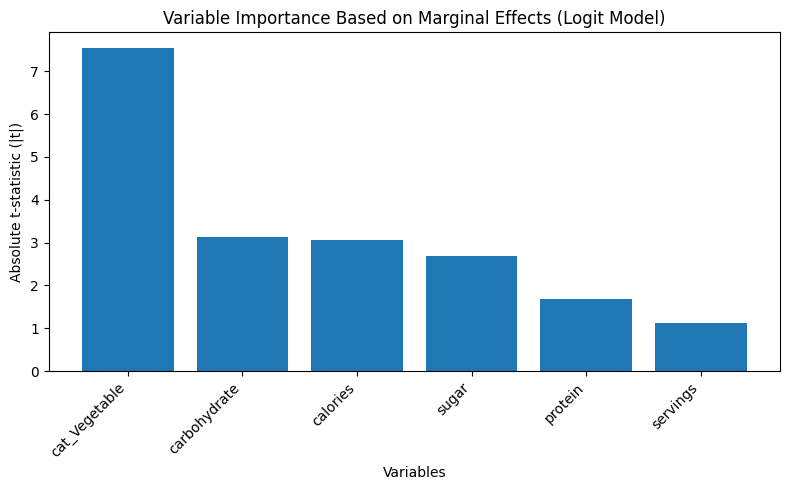

In [ ]:
# Let's plot variables importance for lpm_model
plt.figure(figsize=(8, 5))
plt.bar(
    importance_df.index,
    importance_df['importance']
)

plt.ylabel("Absolute t-statistic (|t|)")
plt.xlabel("Variables")
plt.title("Variable Importance Based on Marginal Effects (Logit Model)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


The graph shows the importance of the variables (using logit model), measured by the absolute value of the t-statistics of the model’s marginal effects. The variables carbohydrates, calories, and sugar are the most influential, with t-statistics close to 3, indicating that their effects on the probability of high traffic are both strong and precisely estimated. In contrast, protein and servings have lower t-statistics, reflecting a less robust effect, while the Vegetable category has an almost zero score, revealing estimation instability due to a quasi-separation issue. Thus, nutritional variables appear to be the most decisive factors in explaining high traffic, whereas some discrete or secondary variables play a more uncertain role.

# 5. Random Forest estimation

In [ ]:
x_train_used = x_train[['calories', 'carbohydrate', 'sugar', 'protein', 'servings', 'cat_Vegetable']]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Let's define our Random forest model
rf_model = RandomForestClassifier(
    n_estimators= 500,
    max_depth= None,
    random_state = 42,
    class_weight='balanced'
)

In [ ]:
# Let's train our Random forest model
rf_model.fit(x_train_used, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [ ]:
# Importance variables
importances = rf_model.feature_importances_
for feature, importance in zip(x_train_used.columns, importances):
  print(f"{feature}: {importance:.4f}")

calories: 0.2176
carbohydrate: 0.1965
sugar: 0.2052
protein: 0.2604
servings: 0.0515
cat_Vegetable: 0.0688


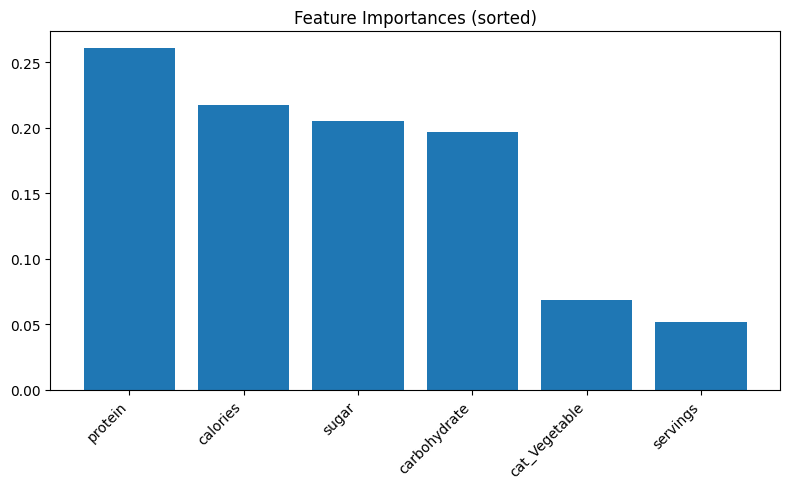

In [ ]:

# Sort feature importances in descending order
sorted_idx = np.argsort(importances)[::-1]

# Reorder feature names and importances
sorted_features = x_train_used.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(sorted_features, sorted_importances)
plt.xticks(rotation=45, ha='right')
plt.title("Feature Importances (sorted)")
plt.tight_layout()
plt.show()
